# Prática: Problemas de Classificação
# Insper AI

---

## Modelo de Classificação e Métricas de Desempenho de um Classificador

Este notebook aplica os conhecimentos da aula 2 em um **problema de classificação** e aborda como avaliar o desempenho de um classificador. O dataset de câncer de mama de Wisconsin será utilizado para prever se um tumor é benigno ou maligno.

### Objetivo:
Desenvolver um modelo de classificação seguindo o workflow de ML e **aprender a avaliar o desempenho do modelo usando métricas apropriadas para classificação**.

### Etapas:
1. **Análise exploratória de Dados (EDA)**  
2. **Preparação dos Dados** 
3. **Implmentação e Treinamento do Modelo** 
4. **Previsões**
5. **Avaliação Crítica do Modelo** (Foco da atividade)

### Instruções:
- Consulte o notebook do último encontro caso tenha dúvidas em relação ao workflow.
- Após concluir, faça a atividade no notebook `lr-bgd.ipynb`.

---

## Começando: Importando bibliotecas e carregando dados

Nessa atividade, usaremos as seguintes bibliotecas:
- **pandas**: Biblioteca para manipulação e análise de dados estruturados.
- **sklearn**: Biblioteca com ferramentas para Machine Learning, incluindo datasets, modelos e métricas.
- **matplotlib**: Biblioteca para criação de visualizações gráficas.

In [1]:
# Importar as bibliotecas necessárias
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

### Descrição do Dataset

O dataset utilizado nessa atividade é o conjunto de dados de câncer de mama de Wisconsin, que contém 569 amostras de tumores de mama, cada uma com 30 características numéricas, como textura, perímetro, área, etc. A variável alvo (`target`) é binária, indicando se o tumor é benigno (0) ou maligno (1).

### Definição do problema e objetivo

O objetivo é classificar os tumores como benignos ou malignos com base nas características extraídas de exames de imagem de aspiração por agulha fina (FNA) de tumores de mama.

---

## 1. Análise exploratória de Dados (EDA)

Explore a estrutura básica dos dados, crie visualizações e analise as relações, buscando:
- **Entender a estrutura dos dados**: dimensões, tipos de variáveis, valores faltantes
- **Analisar a distribuição das variáveis**: histogramas, estatísticas descritivas
- **Identificar relações entre variáveis**: correlações, scatter plots

Shape do dataset: (569, 31)

Primeiras linhas:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture

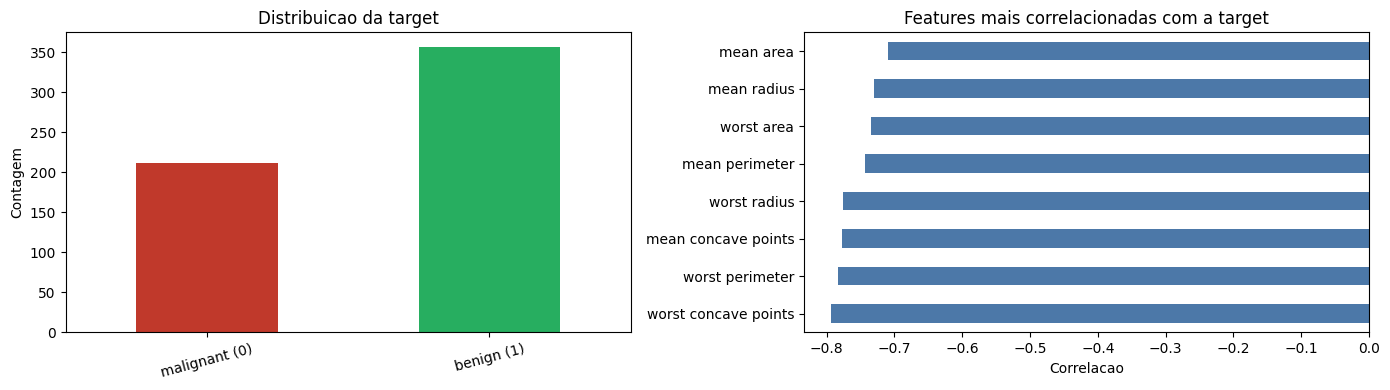

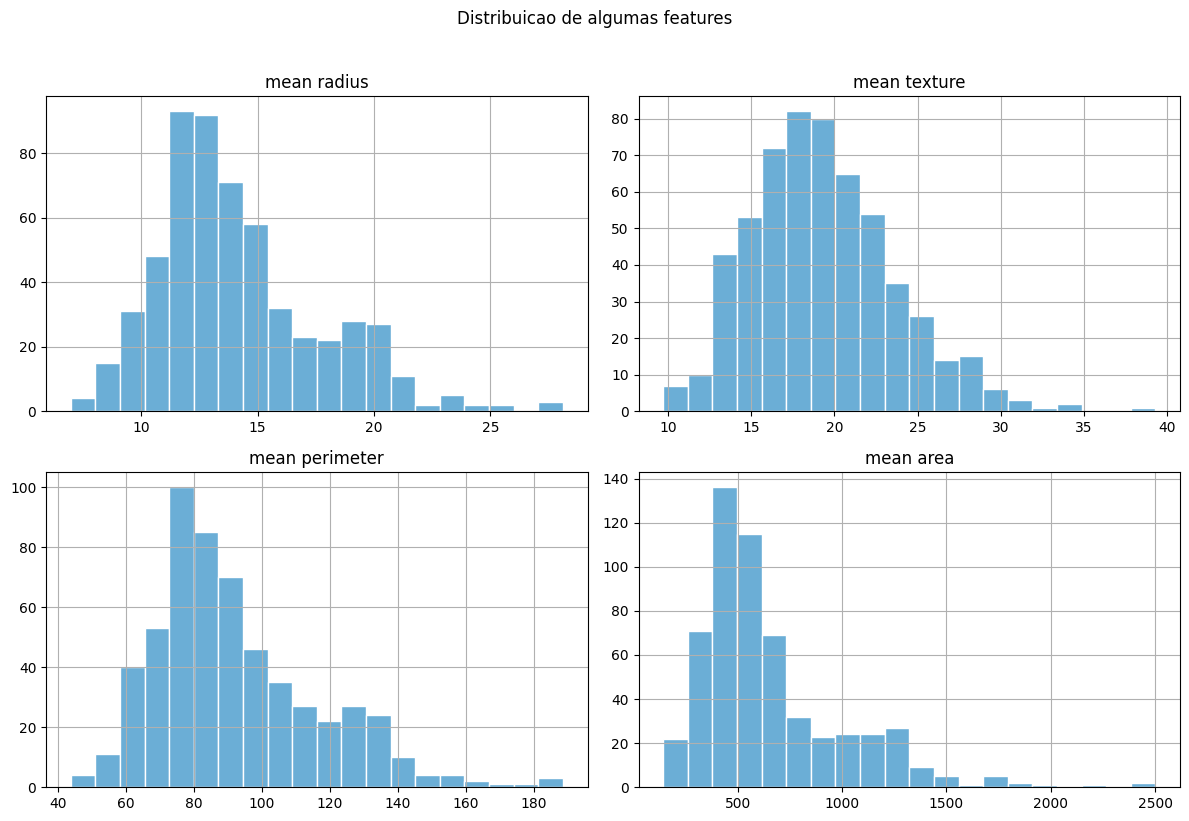

In [3]:
# SEU CÓDIGO AQUI
import matplotlib.pyplot as plt

print(f"Shape do dataset: {df.shape}")
print("\nPrimeiras linhas:")
print(df.head())

print("\nResumo das colunas:")
resumo = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "unicos": df.nunique(),
})
print(resumo)

print("\nDistribuicao da variavel target:")
target_counts = df["target"].value_counts().sort_index()
target_labels = pd.Series(target_counts.values, index=["malignant (0)", "benign (1)"])
print(target_labels)

print("\nEstatisticas descritivas das features (resumo):")
stats = df.drop(columns=["target"]).describe().T[["mean", "std", "min", "50%", "max"]].round(2)
print(stats.head(10))

corr_target = (
    df.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(8)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

target_labels.plot(kind="bar", ax=axes[0], color=["#c0392b", "#27ae60"])
axes[0].set_title("Distribuicao da target")
axes[0].set_ylabel("Contagem")
axes[0].tick_params(axis="x", rotation=15)

corr_target.sort_values().plot(kind="barh", ax=axes[1], color="#4c78a8")
axes[1].set_title("Features mais correlacionadas com a target")
axes[1].set_xlabel("Correlacao")

plt.tight_layout()
plt.show()

features_plot = ["mean radius", "mean texture", "mean perimeter", "mean area"]
df[features_plot].hist(bins=20, figsize=(12, 8), color="#6baed6", edgecolor="white")
plt.suptitle("Distribuicao de algumas features", y=1.02)
plt.tight_layout()
plt.show()


## 2. Preparação dos Dados

Separe o DataFrame em uma matriz de features (X) e um vetor target (y). Em seguida, dividir os dados em conjuntos de treino e teste:
1. Divida os dados em 80% para treino e 20% para teste
2. As variáveis resultantes devem ser: `X_train`, `X_test`, `y_train`, `y_test`
3. Exiba o tamanho de cada conjunto

### Dica
- Use `train_test_split` do scitkit-learn

In [ ]:
# SEU CÓDIGO AQUI

## 3. Implementação e Treinamento do Modelo

**Tarefa**: Instancie e treine um modelo de regressão logística (`LogisticRegression`) usando o *scikit-learn*. Além disso, **exiba os coeficientes e bias do modelo**.

## Dica
- Use `.fit()` do scikit-learn

In [ ]:
# SEU CÓDIGO AQUI

## 4. Previsões

Com o modelo treinado:
1. Gere previsões para os dados teste
2. Exiba as primeiras previsões
3. Crie um DataFrame comparando as previsões com os valores reais

### Dica
- Use `.predict()` do scitkit-learn

In [ ]:
# SEU CÓDIGO AQUI

## 5. Avaliação Crítica do Modelo

Com o modelo treinado e as previsões feitas, a etapa mais importante é **avaliar sua qualidade**.

Para problemas de classificação, dado a natureza da variável target, são necessárias métricas diferentes das utilizadas em regressão de valores contínuos (último encontro).

### Métricas que vamos utilizar:
- **Acurácia**: Percentual de previsões corretas
- **Matriz de Confusão**: Visualização detalhada dos acertos e erros
- **Precisão**: Das previsões positivas, quantas estavam corretas?
- **Recall**: Dos casos positivos reais, quantos foram identificados?
- **F1-Score**: Média harmônica entre precisão e recall

### 5.1 Fronteira de Decisão: Visualizando o que o Modelo Aprendeu

Lembre-se da equação do nosso modelo:

1.  Cálculo linear: $z = \mathbf{w}^T \cdot \mathbf{x} + b$
2.  Probabilidade: $\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$

A função sigmoide $\sigma(z)$ resulta em 0.5 apenas quando sua entrada $z$ é exatamente 0. Portanto, a fronteira de decisão para a Regressão Logística é o conjunto de todos os pontos $\mathbf{x}$ que satisfazem a equação:

$$ \mathbf{w}^T \cdot \mathbf{x} + b = 0 $$

Para um problema com duas features ($x_1, x_2$), essa é a equação de uma **linha reta**: $w_1x_1 + w_2x_2 + b = 0$. Para três features, é a equação de um plano, e assim por diante. É por isso que a Regressão Logística é conhecida como um **classificador linear**.

<div align="center">
<img src="https://codefinity-content-media.s3.eu-west-1.amazonaws.com/b71ff7ac-3932-41d2-a4d8-060e24b00129/DecisionBoundary.png" alt="Fronteira de decisão" width="600"/>
</div>

**Tarefa**: Complete o código abaixo para visualizar a fronteira de decisão do modelo.

Como o modelo principal foi treinado com 30 features, nao conseguimos visualizar sua fronteira de decisao diretamente. Para contornar isso, escolha duas features (por exemplo, `mean radius` e `mean texture`), treine um **modelo auxiliar** de Regressao Logistica usando apenas essas duas features e plote sua fronteira de decisao.

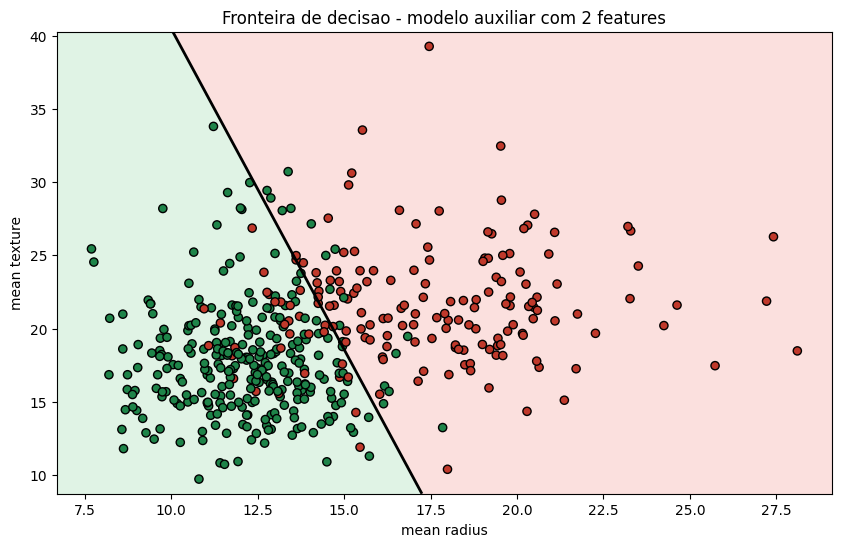

In [ ]:
# SEU CODIGO AQUI
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. Escolha duas features para visualizacao
features_vis = [...]

# 2. Separe essas features e a target
X_vis = ...
y_vis = ...

# 3. Faca a divisao treino/teste
X_train_vis, X_test_vis, y_train_vis, y_test_vis = ...

# 4. Treine um modelo auxiliar de regressao logistica
model_vis = ...
model_vis.fit(...)

# 5. Monte uma grade cobrindo o espaco das duas features
x_min, x_max = X_train_vis.iloc[:, 0].min() - 1, X_train_vis.iloc[:, 0].max() + 1
y_min, y_max = X_train_vis.iloc[:, 1].min() - 1, X_train_vis.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# 6. Calcule as probabilidades previstas para cada ponto da grade
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=features_vis)
proba = model_vis.predict_proba(grid)[:, 1]
proba = proba.reshape(xx.shape)

# 7. Plote os pontos de treino, as regioes previstas e a fronteira (probabilidade = 0.5)
cmap_bg = ListedColormap(['#f4a7a3', '#a8ddb5'])
cmap_pts = ListedColormap(['#c0392b', '#1e8449'])

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, proba >= 0.5, alpha=0.35, cmap=cmap_bg)
plt.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=2)
plt.scatter(
    X_train_vis.iloc[:, 0],
    X_train_vis.iloc[:, 1],
    c=y_train_vis,
    cmap=cmap_pts,
    edgecolor='k',
    s=35
)
plt.xlabel(features_vis[0])
plt.ylabel(features_vis[1])
plt.title('Fronteira de decisao - modelo auxiliar com 2 features')
plt.show()


### 5.3 Matriz de Confusão - Visualização Detalhada

A **Matriz de Confusão** é uma tabela que nos mostra exatamente onde o modelo está acertando e errando. A ideia é dividir as previsões em quatro categorias:

- **Verdadeiros Negativos (TN)**: O modelo previu negativo e o valor real é negativo.
- **Falsos Positivos (FP)**: O modelo previu positivo e o valor real é negativo.
- **Falsos Negativos (FN)**: O modelo previu negativo e o valor real é positivo.
- **Verdadeiros Positivos (TP)**: O modelo previu positivo e o valor real é positivo.

**Tarefa**: Gere a matriz de confusão do modelo usando o método `confusion_matrix` do scikit-learn e interprete os resultados

In [ ]:
# SEU CÓDIGO AQUI

# EXIBIÇÃO
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=cancer.target_names)
disp.plot(cmap='Blues')
disp.ax_.set_title('Matriz de Confusão')
plt.show()

NameError: name 'conf_matrix' is not defined

### 5.4 Precisão e Recall - Métricas Cruciais

Para problemas de classificação, **Precisão** e **Recall** são métricas fundamentais:

#### **Precisão (Precision)**
A precisão mede a exatidão das previsões positivas do modelo, ou seja, ela responde à pergunta, no nosso contexto: "Das vezes que o modelo disse que é MALIGNO, quantas estavam corretas?"

$$\text{Precisão} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

- **Objetivo**: Minimizar falsos positivos (alarme falso)

- **Importância**: Situações onde o custo de um falso positivo é alto (ex: e-mail importante classificado como spam)

**Tarefa**: Calcule a precisão do modelo sem usar as funções prontas do sklearn.

### Dica
- Você pode usar o resultado de `confusion_matrix` para obter os 4 casos

In [ ]:
# SEU CÓDIGO AQUI

#### **Recall (Sensibilidade)**
O recall mede a capacidade do modelo de identificar corretamente os casos positivos reais, ou seja, ele responde à pergunta, no nosso contexto: "De todos os casos MALIGNOS reais, quantos o modelo conseguiu identificar?"

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

- **Objetivo**: Minimizar falsos negativos (perda de casos positivos)

- **Importância**: Situações onde o custo de um falso negativo é alto (ex: diagnóstico incorreto de doenças graves)

**Tarefa**: Calcule o recall do modelo sem usar as funções prontas do sklearn.

In [ ]:
# SEU CÓDIGO AQUI

**Responda**:
- No contexto do câncer de mama, qual métrica (precisão ou recall) você considera mais crítica? Justifique.  

    **R**:

### 5.5 F1-Score: Balanço Entre Precisão e Recall

O **F1-Score** é uma métrica que combina a Precisão e o Recall em um único número. Seu principal objetivo é fornecer uma medida do **equilíbrio** entre essas duas forças opostas.

Ele não é uma média simples, mas sim uma **média harmônica**. Isso porque a média harmônica **penaliza valores extremos de forma mais severa**. Dessa forma, um modelo só terá um F1-Score alto se ambos, Precisão e Recall, forem altos.

**Fórmula:**
$$F1 = 2 \cdot \frac{\text{Precisão} \cdot \text{Recall}}{\text{Precisão} + \text{Recall}}$$


Em resumo, o F1-Score é a sua melhor métrica "padrão" para avaliar um classificador, mas ele nunca deve ser olhado de forma isolada.

**Tarefa**: Calcule e exiba o F1-Score do modelo sem usar as funções prontas do sklearn.

In [ ]:
# SEU CÓDIGO AQUI

### 5.6 Interprete os Resultados

**Tarefa**: Com base na matriz de confusão, na acurácia, na precisão, no recall, na fronteira de decisão e no F1-Score escreva uma interpretação curta do desempenho do modelo.

**Responda**:
- O modelo parece equilibrado entre precisão e recall?  
- Os erros observados parecem aceitáveis para esse problema?  
- O que a fronteira de decisão sugere sobre a capacidade do modelo?  
- Se você fosse melhorar esse classificador, qual seria o próximo passo?  

    **R**: